### Data Selection for Finetuning Ag slab w/ [C, H, O] adsorbates

Download OUTCAR for each pre-screened folder listed in cache/selected_foldernames.txt

In [14]:
import os
import time
import re
from dotenv import load_dotenv
import dropbox
from dropbox.files import SharedLink
from pymatgen.io.vasp.inputs import Incar

load_dotenv(override=True)
TOKEN = os.getenv("DROPBOX_TOKEN")

In [2]:
# read in raw folder names list from cache
with open("cache/selected_foldernames.txt", "r", encoding="utf-8") as f:
    foldernames = [line.strip() for line in f]

print(f"Total items: {len(foldernames)}")

Total items: 139


In [15]:
dbx = dropbox.Dropbox(TOKEN)

ROOT_PATH = SharedLink(url="https://www.dropbox.com/scl/fo/qpg1zuo3g7vb3il1wmqy3/AA4wERzz28lJhYTCAcSEvqk?dl=0")

In [ ]:
# download OUTCAR in every selected folder

no_outcar = []
failed_folders = {}
for folder in foldernames:
    folder_path = f"/{folder}"
    try:
        res = dbx.files_list_folder(path=folder_path, shared_link=ROOT_PATH)
        names = {e.name for e in res.entries}
    except dropbox.exceptions.ApiError as e:
        failed_folders[folder] = str(e)
        print(f"WARNING: list failed -> {folder}: {e}")
        continue
    if "OUTCAR" not in names:
        no_outcar.append(folder)
        print(f"WARNING: no OUTCAR -> {folder}")
        continue
    try:
        _, dres = dbx.sharing_get_shared_link_file(url=ROOT_PATH.url, path=f"{folder_path}/OUTCAR")
        with open(f"outcars/{folder}_OUTCAR", "wb") as f:
            f.write(dres.content)
    except dropbox.exceptions.ApiError as e:
        failed_folders[folder] = str(e)
        print(f"WARNING: download failed -> {folder}: {e}")
    time.sleep(0.2)

In [ ]:
# if folder contains >1 OUTCARs, download the greatest-enumerated one (to get the last frame)

def get_max_outcar_suffix(folder):
    """Return highest OUTCAR-N suffix number, or None if only base OUTCAR exists."""
    folder_path = f"/{folder}"
    res = dbx.files_list_folder(path=folder_path, shared_link=ROOT_PATH)
    names = {e.name for e in res.entries}

    max_n = None
    for name in names:
        m = re.fullmatch(r"OUTCAR-(\d+)", name)
        if m:
            n = int(m.group(1))
            if max_n is None or n > max_n:
                max_n = n
    return max_n

outcar_suffix_map = {}
failed_folders = {}

for folder in foldernames:
    try:
        max_n = get_max_outcar_suffix(folder)
        outcar_suffix_map[folder] = max_n  # None means just base OUTCAR
    except dropbox.exceptions.ApiError as e:
        failed_folders[folder] = str(e)
        print(f"WARNING: failed -> {folder}: {e}")
    time.sleep(0.2)

In [22]:
# download INCAR and max INCAR in every folder (if more than one)

def get_max_incar_suffix(folder):
    """Return highest INCAR-N suffix number, or None if only base INCAR exists."""
    res = dbx.files_list_folder(path=f"/{folder}", shared_link=ROOT_PATH)
    names = {e.name for e in res.entries}
    max_n = None
    for name in names:
        m = re.fullmatch(r"INCAR-(\d+)", name)
        if m:
            n = int(m.group(1))
            if max_n is None or n > max_n:
                max_n = n
    return max_n

def download_incar(folder, incar_name):
    dres_content = dbx.sharing_get_shared_link_file(
        url=ROOT_PATH.url, path=f"/{folder}/{incar_name}"
    )[1].content
    with open(f"incars/{folder}_{incar_name}", "wb") as f:
        f.write(dres_content)

missing_incars = []
failed_incars = {}
for folder in foldernames:
    try:
        max_n = get_max_incar_suffix(folder)
        download_incar(folder, "INCAR")
        if max_n is not None:
            download_incar(folder, f"INCAR-{max_n}")
    except dropbox.exceptions.ApiError as e:
        missing_incars.append(folder)
        failed_incars[folder] = str(e)
        print(f"WARNING: no INCAR -> {folder}")
    time.sleep(0.2)
print(f"Missing INCARs: {len(missing_incars)}")

Missing INCARs: 0


Check energy trajectory of folders that are potentially not relaxations.

In [25]:
# read in OUTCARs containing last frame of each run from downloads in outcar/

def build_suffix_map_from_local(folders, outcar_dir="outcars"):
    suffix_map = {}
    for folder in folders:
        files = os.listdir(outcar_dir)
        max_n = None
        for f in files:
            m = re.fullmatch(rf"{re.escape(folder)}_OUTCAR-(\d+)", f)
            if m:
                n = int(m.group(1))
                if max_n is None or n > max_n:
                    max_n = n
        suffix_map[folder] = max_n
    return suffix_map

outcar_suffix_map = build_suffix_map_from_local(foldernames)

In [26]:
def get_energies(outcar_path):
    energies = []
    with open(outcar_path, "r", errors="ignore") as f:
        for line in f:
            if "free  energy   TOTEN" in line:
                energies.append(float(line.split()[-2]))
    return energies

def get_all_energies_with_bounds(folder, outcar_dir="outcars", suffix_map=None):
    max_n = suffix_map.get(folder) if suffix_map else None
    energies = get_energies(f"{outcar_dir}/{folder}_OUTCAR")
    bounds = [len(energies)]
    if max_n is not None:
        for i in range(1, max_n + 1):
            seg = get_energies(f"{outcar_dir}/{folder}_OUTCAR-{i}")
            energies += seg
            bounds.append(len(energies))
    return energies, bounds[:-1]

In [27]:
def get_max_energy_frame(folder, outcar_dir="outcars", suffix_map=None):
    energies, _ = get_all_energies_with_bounds(folder, outcar_dir, suffix_map)
    if not energies:
        return None, None
    max_idx = max(range(len(energies)), key=lambda i: energies[i])
    return max_idx + 1, energies[max_idx]

def get_max_frames(folders, outcar_dir="outcars", suffix_map=None):
    results = {}
    for folder in folders:
        try:
            step, e = get_max_energy_frame(folder, outcar_dir, suffix_map)
            results[folder] = (step, e)
        except Exception as ex:
            results[folder] = (None, str(ex))
    return results

In [28]:
def get_nsw(folder, max_n, incar_dir="incars"):
    incar_name = "INCAR" if max_n is None else f"INCAR-{max_n}"
    with open(f"{incar_dir}/{folder}_{incar_name}", "r", errors="ignore") as f:
        for line in f:
            if line.strip().upper().startswith("NSW"):
                return int(line.split("=")[1].split()[0])
    return None

def get_last_segment_steps(folder, max_n, outcar_dir="outcars"):
    outcar_name = "OUTCAR" if max_n is None else f"OUTCAR-{max_n}"
    return len(get_energies(f"{outcar_dir}/{folder}_{outcar_name}"))

def compare_to_nsw(folder, outcar_dir="outcars", incar_dir="incars", suffix_map=None):
    max_n = suffix_map.get(folder) if suffix_map else None
    actual = get_last_segment_steps(folder, max_n, outcar_dir)
    nsw = get_nsw(folder, max_n, incar_dir)
    return {"actual": actual, "nsw": nsw, "hit_limit": nsw is not None and actual >= nsw}

In [35]:
import math
import matplotlib.pyplot as plt

def downsample(vals, max_points=30):
    if len(vals) <= max_points:
        return list(range(1, len(vals)+1)), vals
    idx = [round(i * (len(vals)-1) / (max_points-1)) for i in range(max_points)]
    idx = sorted(set(idx))
    return [i+1 for i in idx], [vals[i] for i in idx]

def plot_energy_trajectories(folders, outcar_dir="outcars", incar_dir="incars", suffix_map=None):
    n = len(folders)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]
    for ax, folder in zip(axes, folders):
        try:
            energies, bounds = get_all_energies_with_bounds(folder, outcar_dir, suffix_map)
            steps, e = downsample(energies)
            ax.plot(steps, e, marker="o", markersize=3)
            for b in bounds:
                ax.axvline(x=b, color="red", linestyle="--", linewidth=0.7)
            ax.text(0.98, 0.95, f"n={len(energies)}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8)
            info = compare_to_nsw(folder, outcar_dir, incar_dir, suffix_map=suffix_map)
            hit_text = "yes" if info["hit_limit"] else "no"
            ax.text(0.98, 0.85, f"Hit max ionic steps: {hit_text}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=8,
                    color="red" if info["hit_limit"] else "black")
        except Exception as ex:
            ax.text(0.5, 0.5, f"failed: {ex}", ha="center", va="center")
        ax.set_title(folder, fontsize=9)
        ax.set_xlabel("step")
        ax.set_ylabel("E (eV)")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [5]:
import math
import matplotlib.pyplot as plt

def get_energies(outcar_path):
    energies = []
    with open(outcar_path, "r", errors="ignore") as f:
        for line in f:
            if "free  energy   TOTEN" in line:
                energies.append(float(line.split()[-2]))
    return energies

def get_all_energies(folder, outcar_dir="outcars", suffix_map=None):
    max_n = suffix_map.get(folder) if suffix_map else None
    energies = get_energies(f"{outcar_dir}/{folder}_OUTCAR")
    if max_n is not None:
        for i in range(1, max_n + 1):
            energies += get_energies(f"{outcar_dir}/{folder}_OUTCAR-{i}")
    return energies

def get_all_energies_with_bounds(folder, outcar_dir="outcars", suffix_map=None):
    max_n = suffix_map.get(folder) if suffix_map else None
    energies = get_energies(f"{outcar_dir}/{folder}_OUTCAR")
    bounds = [len(energies)]
    if max_n is not None:
        for i in range(1, max_n + 1):
            seg = get_energies(f"{outcar_dir}/{folder}_OUTCAR-{i}")
            energies += seg
            bounds.append(len(energies))
    return energies, bounds[:-1]  # drop last (end of trajectory, not a boundary)

def downsample(vals, max_points=30):
    if len(vals) <= max_points:
        return list(range(1, len(vals)+1)), vals
    idx = [round(i * (len(vals)-1) / (max_points-1)) for i in range(max_points)]
    idx = sorted(set(idx))
    return [i+1 for i in idx], [vals[i] for i in idx]

def plot_energy_trajectories(folders, outcar_dir="outcars", suffix_map=None):
    n = len(folders)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, folder in zip(axes, folders):
        try:
            # energies = get_all_energies(folder, outcar_dir, suffix_map)
            energies, bounds = get_all_energies_with_bounds(folder, outcar_dir, suffix_map)
            steps, e = downsample(energies)
            ax.plot(steps, e, marker="o", markersize=3)
            for b in bounds:
                ax.axvline(x=b, color="red", linestyle="--", linewidth=0.7)
            ax.text(0.98, 0.95, f"n={len(energies)}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8)
            
            
            steps, e = downsample(energies)
            ax.plot(steps, e, marker="o", markersize=3, color="C0")
            ax.text(0.98, 0.95, f"n={len(energies)}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8)
        except Exception as ex:
            ax.text(0.5, 0.5, f"failed: {ex}", ha="center", va="center")
        ax.set_title(folder, fontsize=9)
        ax.set_xlabel("step")
        ax.set_ylabel("E (eV)")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [20]:
# check max energy of DFT run
def get_max_energy_frame(folder, outcar_dir="outcars", suffix_map=None):
    energies, _ = get_all_energies_with_bounds(folder, outcar_dir, suffix_map)
    if not energies:
        return None, None
    max_idx = max(range(len(energies)), key=lambda i: energies[i])
    return max_idx + 1, energies[max_idx]  # 1-indexed step

# check which frame the max energy occurs at
def get_max_frames(folders, outcar_dir="outcars", suffix_map=None):
    results = {}
    for folder in folders:
        try:
            step, e = get_max_energy_frame(folder, outcar_dir, suffix_map)
            results[folder] = (step, e)
        except Exception as ex:
            results[folder] = (None, str(ex))
    return results

# usage:
# get_max_frames(foldernames, suffix_map=outcar_suffix_map)

In [30]:
get_max_energy_frame("O4Ag_Tetra_2", suffix_map=outcar_suffix_map)

(1, -125.1472579)

In [31]:
allfolders = [
    "2OAg",
    "2O_subAg",
    "O4Ag_Tetra_1",
    "O4Ag_Tetra_2",
    "O2Above_OonAg",
    "1Oalt_OsubAg_2x2",
    "OMC_Ag_rec0",
    "OMC_Ag_rec1",
    "OMC_Ag_rec2",
    "OMC_Ag_rec3",
    "OMC+O_Ag0",
    "OCCO_Ag0",
    "OMC+O_Ag1",
    "OCCO_Ag1_good",
    "OCCO_Ag4_good",
    "OCCO_Ag2_good",
    "OCCO_Ag3_good",
    "OCCO_Ag5",
    "O+OCCO_Ag0",
    "O+OCCO_Ag1",
    "O+OCCO_Ag2",
    "O+OMC_Ag0",
    "O+OMC_Ag5",
    "O+OMC_Ag1",
    "O+OMC_Ag2",
    "O+OMC_Ag3",
    "O+OMC_Ag4",
    "O+OMC_HToO_Ag1",
    "O+OMC_HToO_Ag2",
    "O+OMC_HToO_Ag5",
    "CO3_Ag0",
    "CO3_Ag1",
    "CO3_Ag2",
    "PropOMC_Ag0",
    "PropOMC_Ag2",
    "PropOMC_Ag1",
    "PropOMC_Ag3",
    "PropOCCO_Ag0",
    "PropOCCO_Ag3",
    "PropOCCO_Ag5",
    "PropOCCO_Ag1",
    "PropOCCO_Ag2",
    "PropOCCO_Ag4",
    "PropOCCO_Ag6",
    "PropOCCO_Ag7",
    "O+PropOMC_Ag0",
    "O+PropOMC_Ag1",
    "O+PropOMC_Ag2",
    "Ag_rec_0_1_vac79",
    "Ag_rec_0_1_vac81",
    "Ag_rec_0_O_1",
    "Ag_rec_0_O_0",
    "OxideRing",
    "O_subAg_100_2",
    "O_subAg_100_3",
    "OAg_100_2x2_0",
    "OAg_100_2x2_4",
    "OAg_100_2x2_1",
    "OAg_100_2x2_2",
    "OAg_100_2x2_3",
    "Ag_100_2x2",
    "O2AdsAg_100_1",
    "OAg_100_2x4_rec_0",
    "OAg_100_2x4_rec_1",
    "CO3_Ag_2x2_0",
    "CO3_Ag_2x2_1",
    "CO3_Ag_2x2_2",
    "AgAdatom_Ag_100",
    "O_AgAdatom_Ag_100_0",
    "O_AgAdatom_Ag_100_1",
    "O_AgAdatom_Ag_100_2",
    "O_AgAdatom_Ag_100_3",
    "O_subAg_100_more1",
    "O_subAg_100_more2",
    "O_subAg_100_more3",
    "O_subAg_100_more4",
    "O_subAg_100_more5",
    "O+water_Ag_100_1",
    "O+water_Ag_100_3",
    "O+water_Ag_100_2",
    "OH_Ag_100_1",
    "OAgChain_Ag_100_more1",
    "OAg_100_4x4_vac_1",
    "OAg_100_4x4_vac_8",
    "OAg_100_4x4_vac_9",
    "OAg_100_4x4_vac_10",
    "OAg_100_4x4_vac_11",
    "OAg_100_4x4_vac_2",
    "OAg_100_4x4_vac_3",
    "OAg_100_4x4_vac_4",
    "OAg_100_4x4_vac_5",
    "OAg_100_4x4_vac_6",
    "OAg_100_4x4_vac_7",
    "OAg_100_4x4_vac_more_1",
    "OAg_100_4x4_vac_more_2",
    "OAg_100_4x4_vac_more_3",
    "Ag_rec_0_CO3_vac_79",
    "Ag_rec_0_CO3_vac_77",
    "Ag_rec_0_OCCO_vac_79_0",
    "Ag_rec_0_OCCO_vac_77_2",
    "Ag_rec_0_OCCO_vac_79_1",
    "OCCO_Ag_2x2",
    "Ag_rec_0_OCCO_0",
    "Ag_rec_0_OCCO_1",
    "Ag_rec_0_OCCO_2",
    "Ag_rec_0_OCCO_more_0",
    "Ag_2x1",
    "OCCO_Ag_2x1",
    "Ag_rec_0_OCCO_more3_0",
    "OAg_100_4x4_sub_1",
    "OAg_100_4x4_sub_2",
    "OAg_100_4x4_sub_3",
    "OAg_100_4x4_sub_4",
    "Ag100_O5Phase",
    "Ag100_AddedRow_2x3",
    "Ag100_O5Phase_nosub",
    "Ag100_NewOChain",
    "Ag100_NewOChain2",
    "Ag100_AddedRowNoO_2x3",
    "Ag100_O+Ethylene_1",
    "Ag100_O+Ethylene_2",
    "Ag100_O+Ethylene_3",
    "Ag100_OMC",
    "Ag100_EDO",
    "Ag100_O+Ethylene_4",
    "Ag100_Ethylene_1",
    "O+O_sub_5x5_vac",
    "O+O_sub_5x5",
    "Ag_100_2x4_rec",
    "CO3_Osub_Ag111_2x2",
    "O2_Osub_Ag100",
    "CO3_Ag100_2x2_1",
    "CO3_Ag100_3x3_1",
    "CO3_Osub_Ag100",
    "CO3_Osub_Ag100_alt",
    "CO3_Osub_Ag100_alt2",
    "CO3_Osub_Ag100_2x2",
    "Ag100_O5Phase_CO3Substitution",
    "Ag100_O5Phase_O2",
    "Ag100_O5Phase_Ovac",
    "Ag100_O5Phase_CO3Substitution_withsub",
    "Ag100_O5Phase_O2_withsub",
    "Ag100_O5Phase_Ovac_withsub",
]

In [33]:
compare_to_nsw(folder, suffix_map=outcar_suffix_map)

{'actual': 344, 'nsw': 400, 'hit_limit': False}

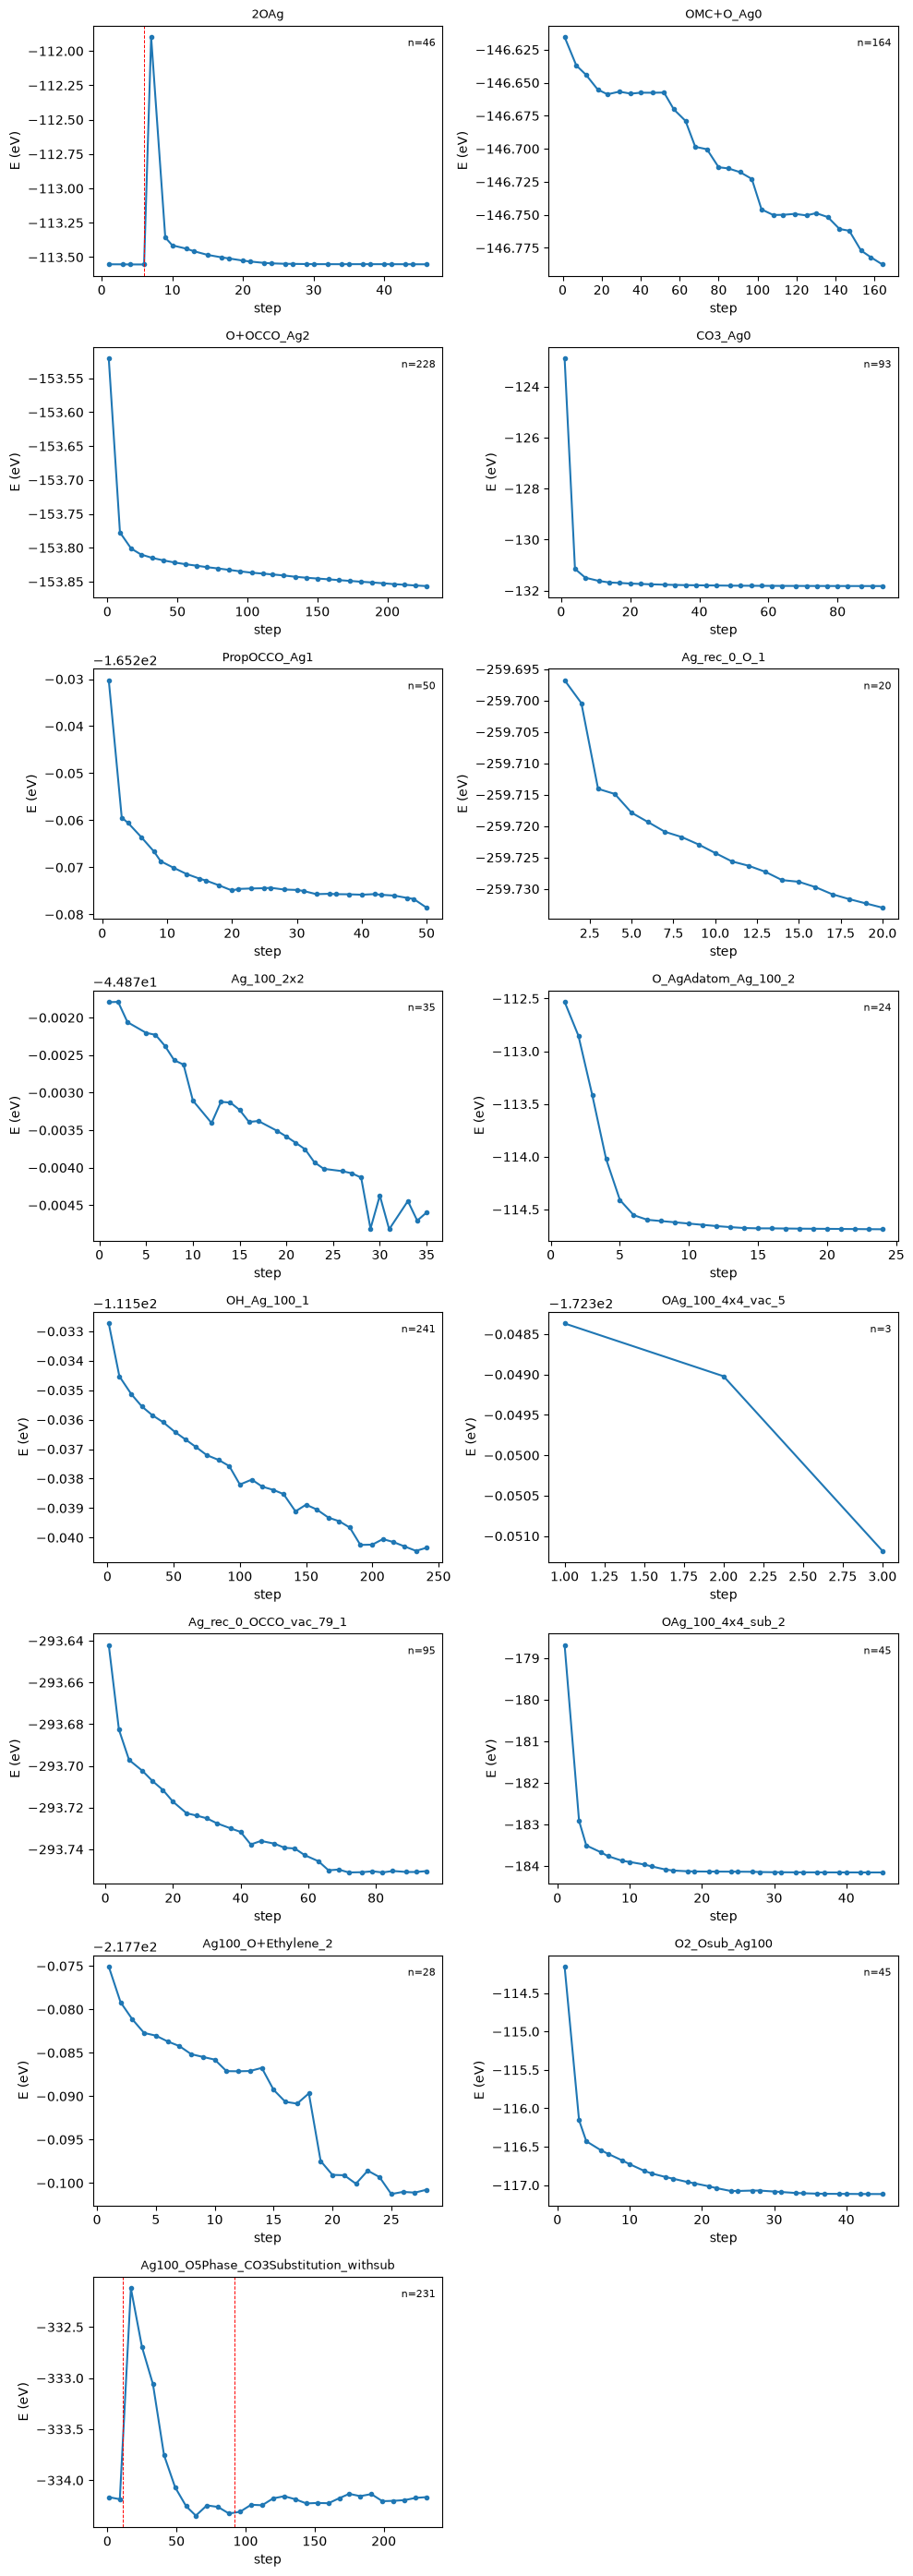

In [12]:
folderlist = allfolders[0::10]
plot_energy_trajectories(folderlist, suffix_map=outcar_suffix_map)

Based on visual inspection of ionic step vs. energy (ev) plots, these don't look like nicely-converged relaxations (and have been removed):
(old list, ignore)
* 1Oalt_OsubAg_2x2
* O2Above_OonAg
* 2OAg (too few frames, n=6)
* OCCO_Ag0 (linear, doesn't look properly converged)
* O+OMC_HToO_Ag1, 2, 5 (those don't look like converged relaxations to me...)

(revised list)
* Tetra everything

Get "first" and last frame of each OUTCAR